In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fastnc

# Shell thickness effect
This notebook studies the effeect of shell thickness effect on the bispectrum.

We studied this effect for debugging. We had a discrepancy between the simulation measuremenets and theory and thought this is one of the cause, but in the end this turned out to be **not** the cause.

In [2]:
def get(nzbin_log=10, nzbin_lin=20):
    bs = fastnc.bispectrum.BispectrumHalofit(Lmax=30, nzbin_log=nzbin_log, nzbin_lin=nzbin_lin)
    cosmo = fastnc.bispectrum.wPlanck18
    bs.set_cosmology(cosmo)
    # nz
    bs.set_source_distribution([1], [1])
    bs.compute_kernel()

    # The shape of matter power spectrum is independent of redshift
    # and the amplitude is normalized to z=0, so that it gives input sigma8
    k, pklin = np.loadtxt('/Users/sugiyamasunao/documents/projects/fastnc/docs/pklin_P18.dat', unpack=True)
    bs.set_pklin(k, pklin)
    # linear growth rate is also needed for the computation
    z, lgr = np.loadtxt('/Users/sugiyamasunao/documents/projects/fastnc/docs/lgr_P18.dat', unpack=True)
    bs.set_lgr(z, lgr)

    return bs.halofit, bs.z2chi

In [3]:
halofit, z2r = get()

In [4]:
k = np.logspace(-4, 1, 100)
z = np.linspace(0, 2, 50)
pklin  = np.array([halofit.get_interpolated_pklin(k, _z) for _z in z])
pkhalo = halofit.get_pkhalofit(k, z)

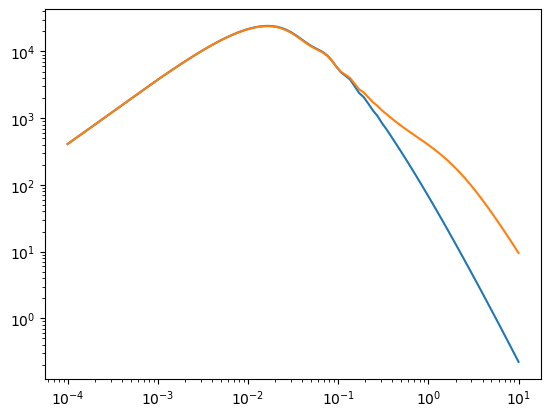

In [5]:
plt.figure()
plt.xscale('log')
plt.yscale('log')
plt.plot(k, pklin[0,:])
plt.plot(k, pkhalo[0,:])
plt.show()

In [74]:
def sinc(x):
    out = np.ones_like(x)
    out[x!=0] = np.sin(x[x!=0])/x[x!=0]
    return out

def get_effective_Pl(l, z, r, P_of_k, dr, n=6, nxbin=100):
    x = np.linspace(0, n*np.pi, nxbin)
    dx= x[1]-x[0]
    k = np.sqrt((l[:,None]/r)**2+(x[None,:]/dr)**2)
    i = P_of_k(k.ravel(), [z]).reshape(k.shape) * sinc(x/2)**2 / (2*np.pi)
    o = 2*dx*np.sum(i, axis=1)
    return o

def get_Pl(l, z, r, P_of_k):
    return P_of_k(l/r, [z])[0]

In [75]:
P_of_k = halofit.get_pkhalofit

l = np.logspace(0, 4, 100)
z = 0.4
r = z2r(z)
dr = 100.0
%time ps = get_effective_Pl(l, z, r, P_of_k, dr)
%time p  = get_Pl(l, z, r, P_of_k)

CPU times: user 8.12 ms, sys: 14.5 ms, total: 22.6 ms
Wall time: 21.9 ms
CPU times: user 1.92 ms, sys: 224 µs, total: 2.14 ms
Wall time: 2.04 ms


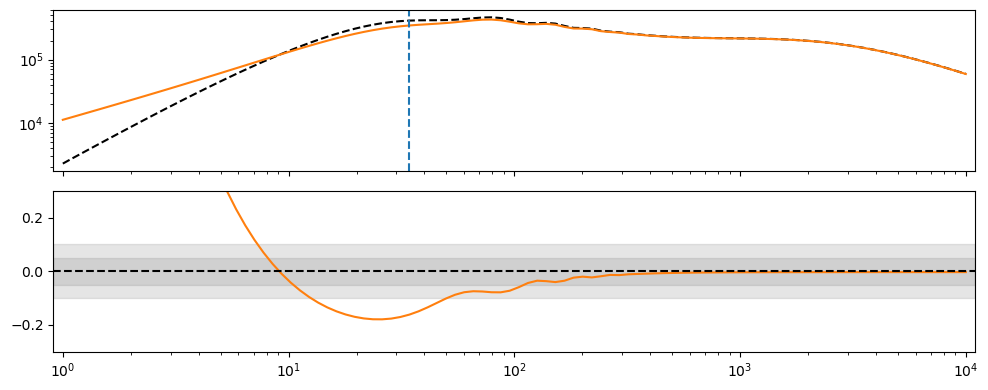

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*p , 'k--')
axes[0].loglog(l, l*ps, 'C1')
axes[0].axvline(np.pi*z2r(z)/dr, ls='--')
axes[1].semilogx(l, ps/p-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
plt.tight_layout()
plt.show()

In [118]:
def get_q_of_r(z2r, zs=1.0):
    rs= z2r(zs)
    z = np.linspace(0, zs, 100)
    r = z2r(z)
    q = (1+z)*r*(rs-r)/rs
    q_of_r = lambda r_in: np.interp(r_in, r, q, right=0.0)
    return q_of_r
    
def get_Cl_shell(l, redges, P_of_k, qa_of_r, qb_of_r, n=6, nxbin=100):
    """
    redges
    r1 : lower edge of shell
    r2 : upper edge of shell
    """
    r1 = redges[:-1]
    r2 = redges[1:]
    dr  = r2 - r1
    r   = (r1+r2)/2
    reff= 3.0/4.0 * (r2**4-r1**4)/(r2**3-r1**3)
    _   = np.linspace(0, 5, 100)
    z   = np.interp(r, z2r(_), _)
    qa  = qa_of_r(r)
    qb  = qb_of_r(r)
    p   = np.array([get_effective_Pl(l, z[i], reff[i], P_of_k, dr[i], n=n, nxbin=nxbin) for i in range(len(z))])
    cl  = np.sum(dr/reff**2*qa*qb*p.T, axis=1)
    return cl

def get_Cl(l, P_of_k, qa_of_r, qb_of_r, r_of_z, zmin=0.0, zmax=1.0, nzbin=100):
    z = np.linspace(zmin, zmax, nzbin+1)
    r = r_of_z(z)
    dr= r[1:]-r[:-1]
    r = (r[1:]+r[:-1])/2
    z = (z[1:]+z[:-1])/2
    
    qa= qa_of_r(r)
    qb= qb_of_r(r)
    p = np.array([P_of_k(l/r[i], [z[i]])[0] for i in range(len(z))])
    cl= np.sum(dr/r**2*qa*qb*p.T, axis=1)
    return cl

In [169]:
q_of_r = get_q_of_r(z2r, 1.0)
redges = np.arange(0, 3000, 450.0)
%time Cls = get_Cl_shell(l, redges, P_of_k, q_of_r, q_of_r)
%time Cl  = get_Cl(l, P_of_k, q_of_r, q_of_r, z2r)

CPU times: user 42.4 ms, sys: 9.38 ms, total: 51.7 ms
Wall time: 55.1 ms
CPU times: user 129 ms, sys: 4.36 ms, total: 133 ms
Wall time: 158 ms


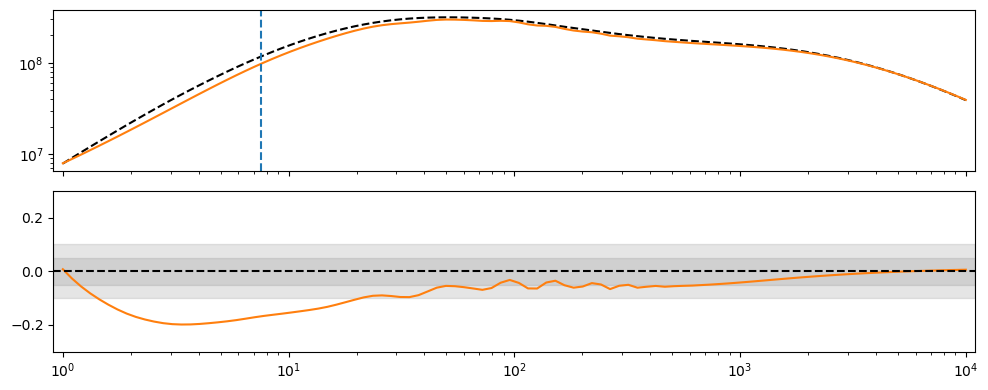

In [170]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*Cl, 'k--')
axes[0].loglog(l, l*Cls, 'C1')
axes[0].axvline(np.pi*z2r(z)/dr, ls='--')
axes[1].semilogx(l, Cls/Cl-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
plt.tight_layout()
plt.show()

## Bispectrum

In [153]:
def get_effective_Bl(l1, l2, l3, z, r, B_of_k, dr, n=6, nxbin=50):
    x = np.linspace(0       , n*np.pi,  nxbin)
    y = np.linspace(-n*np.pi, n*np.pi,2*nxbin)
    dx= x[1]-x[0]
    dy= y[1]-y[0]
    x, y = np.meshgrid(x, y)
    x, y = x.ravel(), y.ravel()
    
    k1 = np.sqrt((l1[:,None]/r)**2+(x[None,:]/dr)**2)
    k2 = np.sqrt((l2[:,None]/r)**2+(y[None,:]/dr)**2)
    k3 = np.sqrt((l3[:,None]/r)**2+((x+y)[None,:]/dr)**2)
    if np.isscalar(z):
        z = np.ones_like(k1)*z

    i = B_of_k(k1.ravel(), k2.ravel(), k3.ravel(), z.ravel()).reshape(z.shape) * sinc(x/2)*sinc(y/2)*sinc((x+y)/2) / (2*np.pi)**2
    o = 2*dx*dy*np.sum(i, axis=1)
    
    return np.array(o)

def get_Bl(l1, l2, l3, z, r, B_of_k):
    return B_of_k(l1/r, l2/r, l3/r, np.ones_like(l1)*z)

In [195]:
B_of_k = halofit.get_bihalofit

l = np.logspace(0, 4, 100)
# k1, k2 = 2, 2.5
k1, k2 = 1, 1
z = 0.4
dr = 80.0
%time bs = get_effective_Bl(l, l*k1, l*k2, z, r, B_of_k, dr)
%time b  = get_Bl(l, l*k1, l*k2, z, r, B_of_k)

CPU times: user 1.38 s, sys: 175 ms, total: 1.55 s
Wall time: 2.06 s
CPU times: user 2.1 ms, sys: 465 µs, total: 2.56 ms
Wall time: 2.52 ms


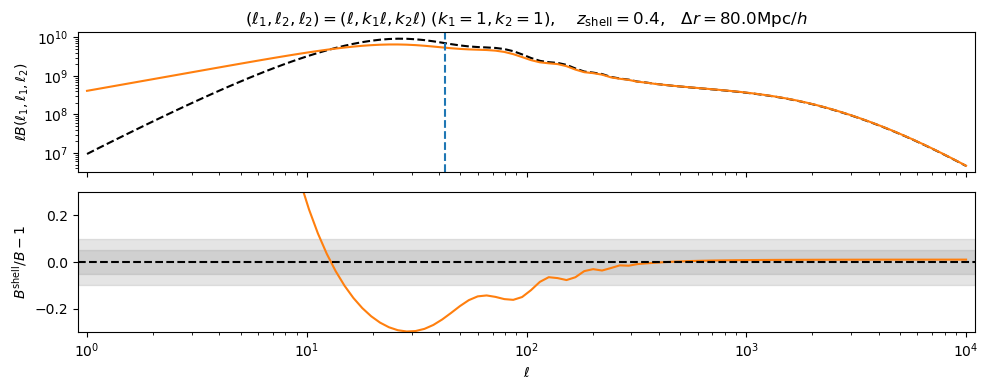

In [196]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*b , 'k--')
axes[0].loglog(l, l*bs, 'C1')
axes[0].axvline(np.pi*z2r(z)/dr, ls='--')
axes[1].semilogx(l, bs/b-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
axes[1].set_xlabel(r'$\ell$')
axes[1].set_ylabel(r'$B^{\rm shell}/B-1$')
axes[0].set_ylabel(r'$\ell B(\ell_1, \ell_1, \ell_2)$')
axes[0].set_title(r'$(\ell_1, \ell_2,\ell_2)=(\ell, k_1\ell, k_2\ell)$ $(k_1={}, k_2={})$,    $z_{{\rm shell}}={}$,   $\Delta r={}{{\rm Mpc}}/h$'.format(k1, k2, z, dr))
plt.tight_layout()
plt.show()

In [200]:
def get_Bkl_shell(l1, l2, l3, redges, B_of_k, qa_of_r, qb_of_r, qc_of_r, n=6, nxbin=100):
    """
    redges
    r1 : lower edge of shell
    r2 : upper edge of shell
    """
    r1 = redges[:-1]
    r2 = redges[1:]
    dr  = r2 - r1
    r   = (r1+r2)/2
    reff= 3.0/4.0 * (r2**4-r1**4)/(r2**3-r1**3)
    _   = np.linspace(0, 5, 100)
    z   = np.interp(r, z2r(_), _)
    qa  = qa_of_r(r)
    qb  = qb_of_r(r)
    qc  = qc_of_r(r)
    b   = np.array([get_effective_Bl(l1, l2, l3, z[i], reff[i], B_of_k, dr[i], n=7, nxbin=nxbin) for i in range(len(z))])
    # bl  = np.sum(dr/reff**4*qa*qb*qc*b.T, axis=1)
    bl  = np.sum(dr/reff*qa*qb*qc*b.T, axis=1)
    return bl

def get_Bkl(l1, l2, l3, B_of_k, qa_of_r, qb_of_r, qc_of_r, r_of_z, zmin=0.0, zmax=1.0, nzbin=100):
    z = np.linspace(zmin, zmax, nzbin+1)
    r = r_of_z(z)
    dr= r[1:]-r[:-1]
    r = (r[1:]+r[:-1])/2
    z = (z[1:]+z[:-1])/2
    
    qa= qa_of_r(r)
    qb= qb_of_r(r)
    qc= qc_of_r(r)
    b = np.array([get_Bl(l1, l2, l3, z[i], r[i], B_of_k) for i in range(len(z))])
    # bl= np.sum(dr/r**4*qa*qb*qc*b.T, axis=1)
    bl= np.sum(dr/r*qa*qb*qc*b.T, axis=1)
    return bl

In [201]:
k1, k2 = 1, 1
dr = 80.0
redges = np.arange(0, 3000, dr)
%time Bls = get_Bkl_shell(l, l*k1, l*k2, redges, B_of_k, q_of_r, q_of_r, q_of_r)
%time Bl  = get_Bkl(l, l*k1, l*k2, B_of_k, q_of_r, q_of_r, q_of_r, z2r)

CPU times: user 3min 50s, sys: 29.8 s, total: 4min 20s
Wall time: 4min 27s
CPU times: user 202 ms, sys: 2.82 ms, total: 205 ms
Wall time: 206 ms


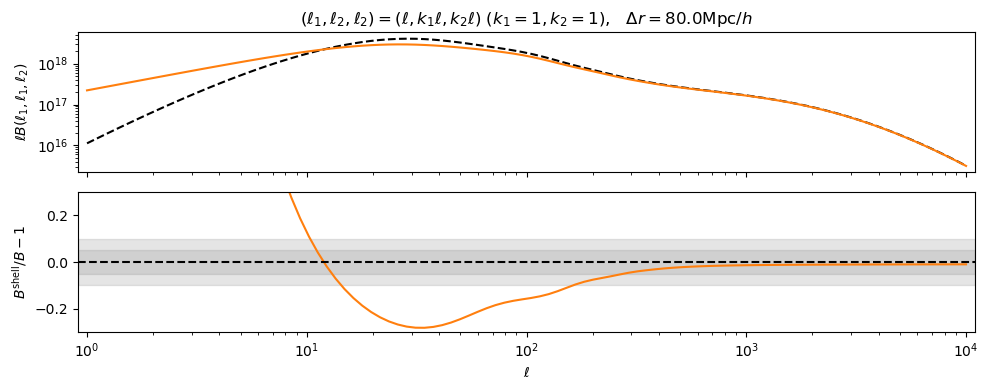

In [203]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*Bl , 'k--')
axes[0].loglog(l, l*Bls, 'C1')
axes[1].semilogx(l, Bls/Bl-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
axes[1].set_xlabel(r'$\ell$')
axes[1].set_ylabel(r'$B^{\rm shell}/B-1$')
axes[0].set_ylabel(r'$\ell B(\ell_1, \ell_1, \ell_2)$')
axes[0].set_title(r'$(\ell_1, \ell_2,\ell_2)=(\ell, k_1\ell, k_2\ell)$ $(k_1={}, k_2={})$,   $\Delta r={}{{\rm Mpc}}/h$'.format(k1, k2, dr))
plt.tight_layout()
plt.show()

In [204]:
k1, k2 = 1.2, 1.5
dr = 80.0
redges = np.arange(0, 3000, dr)
%time Bls = get_Bkl_shell(l, l*k1, l*k2, redges, B_of_k, q_of_r, q_of_r, q_of_r)
%time Bl  = get_Bkl(l, l*k1, l*k2, B_of_k, q_of_r, q_of_r, q_of_r, z2r)

CPU times: user 4min 23s, sys: 35.5 s, total: 4min 58s
Wall time: 5min 23s
CPU times: user 319 ms, sys: 40.4 ms, total: 359 ms
Wall time: 420 ms


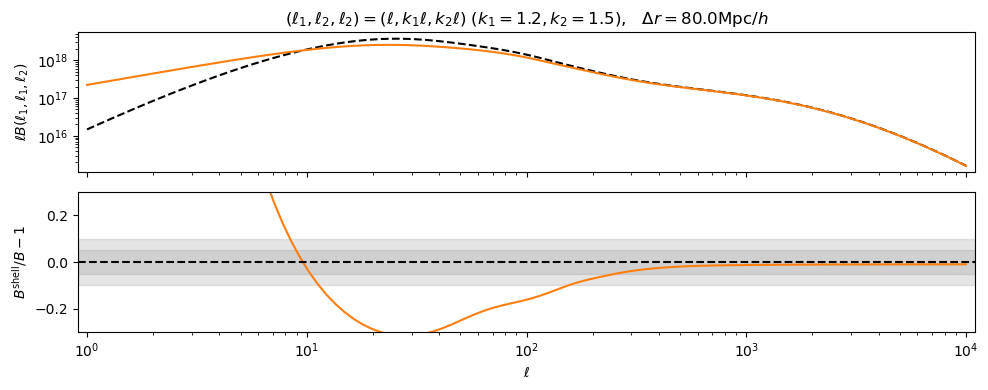

In [205]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*Bl , 'k--')
axes[0].loglog(l, l*Bls, 'C1')
axes[1].semilogx(l, Bls/Bl-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
axes[1].set_xlabel(r'$\ell$')
axes[1].set_ylabel(r'$B^{\rm shell}/B-1$')
axes[0].set_ylabel(r'$\ell B(\ell_1, \ell_1, \ell_2)$')
axes[0].set_title(r'$(\ell_1, \ell_2,\ell_2)=(\ell, k_1\ell, k_2\ell)$ $(k_1={}, k_2={})$,   $\Delta r={}{{\rm Mpc}}/h$'.format(k1, k2, dr))
plt.tight_layout()
plt.show()

In [209]:
zedges = np.linspace(0, 3.5, 70)
redges = z2r(zedges)

k1, k2 = 1., 1.
%time Bls = get_Bkl_shell(l, l*k1, l*k2, redges, B_of_k, q_of_r, q_of_r, q_of_r)
%time Bl  = get_Bkl(l, l*k1, l*k2, B_of_k, q_of_r, q_of_r, q_of_r, z2r)

CPU times: user 7min 39s, sys: 1min 2s, total: 8min 42s
Wall time: 9min 46s
CPU times: user 286 ms, sys: 23.6 ms, total: 310 ms
Wall time: 346 ms


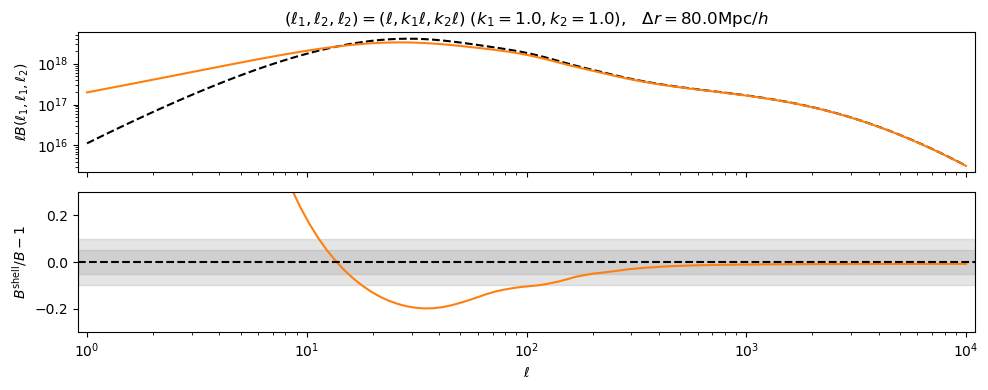

In [211]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].loglog(l, l*Bl , 'k--')
axes[0].loglog(l, l*Bls, 'C1')
axes[1].semilogx(l, Bls/Bl-1, color='C1')
axes[1].axhline(0, ls='--', color='k')
axes[1].axhspan(-0.10, 0.10, color='gray', alpha=0.2)
axes[1].axhspan(-0.05, 0.05, color='gray', alpha=0.2)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_xlim(l.min()/1.1, l.max()*1.1)
axes[1].set_xlabel(r'$\ell$')
axes[1].set_ylabel(r'$B^{\rm shell}/B-1$')
axes[0].set_ylabel(r'$\ell B(\ell_1, \ell_1, \ell_2)$')
axes[0].set_title(r'$(\ell_1, \ell_2,\ell_2)=(\ell, k_1\ell, k_2\ell)$ $(k_1={}, k_2={})$,   $\Delta r={}{{\rm Mpc}}/h$'.format(k1, k2, dr))
plt.tight_layout()
plt.show()